# Prediction of PD - Level 3

In [1]:
!pip install -U pip
!pip install autogluon.tabular[all]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
INFO: This is 

In [2]:
!pip install -q shap lime

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os
import json
import math
import warnings
from pathlib import Path
import shutil
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

from autogluon.tabular import TabularPredictor

import shap
from lime.lime_tabular import LimeTabularExplainer

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.calibration import calibration_curve


warnings.filterwarnings("ignore")

# 0) User Config

In [4]:
TRAIN_PATH = "/content/train_raw.csv"
VAL_PATH   = "/content/val_raw.csv"
TEST_PATH  = "/content/test_raw.csv"

OUT_DIR = "/content/autogluon_level3_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

EXPLAIN_DIR = os.path.join(OUT_DIR, "explainability")
os.makedirs(EXPLAIN_DIR, exist_ok=True)

PLOT_DIR = "/content/thesis_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET = "Default"

SEED = 42

TIME_LIMIT = 600 # for summery

CONSERVATISM_UPLIFT = 0.30

APPLY_PD_FLOOR = True
PD_FLOOR = 0.0005

MOC_A_UPLIFT = 0.05

# Bootstrap sizes, lower numbers as each time a new model is created --> high costs
N_BOOT_TEST = 5
N_BOOT_TRAIN = 3
BOOTSTRAP_TIME_LIMIT = 60

# Rating-grade logic
N_RISK_GRADES = 10
MIN_GRADE_SHARE = 0.03       # minimum 3% per grade, used as diagnostic


# 1) Load fixed splits

In [5]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (153207, 17)
Val shape: (51070, 17)
Test shape: (51070, 17)


In [6]:
train = train.dropna(subset=[TARGET]).copy()
val = val.dropna(subset=[TARGET]).copy()
test = test.dropna(subset=[TARGET]).copy()

train[TARGET] = train[TARGET].astype(int)
val[TARGET] = val[TARGET].astype(int)
test[TARGET] = test[TARGET].astype(int)

In [7]:
#print(train["Default"].isna().sum())
#print(train.loc[12764])

# 2) Helper functions

In [8]:
def logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))


def inv_logit(z):
    return 1 / (1 + np.exp(-np.asarray(z, dtype=float)))


def ks_statistic(y_true, pd_pred):
    tmp = pd.DataFrame({
        "y": np.asarray(y_true).astype(int),
        "pd": np.asarray(pd_pred)
    }).sort_values("pd", ascending=False)

    total_bad = max((tmp["y"] == 1).sum(), 1)
    total_good = max((tmp["y"] == 0).sum(), 1)

    cum_bad = (tmp["y"] == 1).cumsum() / total_bad
    cum_good = (tmp["y"] == 0).cumsum() / total_good

    return float(np.max(np.abs(cum_bad - cum_good)))


def calibration_table(y_true, pd_pred, n_buckets=10):
    tmp = pd.DataFrame({
        "y": np.asarray(y_true).astype(int),
        "pd": np.asarray(pd_pred)
    })

    tmp["bucket"] = pd.qcut(tmp["pd"], q=n_buckets, duplicates="drop")

    out = tmp.groupby("bucket", observed=False).agg(
        obs=("y", "count"),
        defaults=("y", "sum"),
        avg_pd=("pd", "mean"),
        pd_min=("pd", "min"),
        pd_max=("pd", "max"),
    ).reset_index()

    out["observed_dr"] = out["defaults"] / out["obs"]
    out["calibration_gap"] = out["avg_pd"] - out["observed_dr"]

    return out


def hosmer_lemeshow_like(y_true, pd_pred, n_buckets=10):
    tab = calibration_table(y_true, pd_pred, n_buckets)
    eps = 1e-8

    expected_bad = np.clip(tab["avg_pd"] * tab["obs"], eps, None)
    expected_good = np.clip((1 - tab["avg_pd"]) * tab["obs"], eps, None)

    observed_bad = tab["defaults"]
    observed_good = tab["obs"] - tab["defaults"]

    hl = ((observed_bad - expected_bad) ** 2 / expected_bad).sum()
    hl += ((observed_good - expected_good) ** 2 / expected_good).sum()

    return float(hl)


def evaluate_pd(y_true, pd_pred, prefix):
    auc = roc_auc_score(y_true, pd_pred)

    return {
        f"{prefix}_auc": float(auc),
        f"{prefix}_gini": float(2 * auc - 1),
        f"{prefix}_ks": ks_statistic(y_true, pd_pred),
        f"{prefix}_brier": float(brier_score_loss(y_true, pd_pred)),
        f"{prefix}_logloss": float(log_loss(y_true, pd_pred)),
        f"{prefix}_hl_like": hosmer_lemeshow_like(y_true, pd_pred),
        f"{prefix}_mean_pd": float(np.mean(pd_pred)),
        f"{prefix}_obs_dr": float(np.mean(y_true)),
    }


def population_stability_index(reference, current, buckets=10):
    reference = pd.Series(reference).astype(float)
    current = pd.Series(current).astype(float)

    cuts = np.unique(np.quantile(reference, np.linspace(0, 1, buckets + 1)))

    if len(cuts) < 3:
        return 0.0

    cuts[0] = -np.inf
    cuts[-1] = np.inf

    reference_bins = pd.cut(reference, bins=cuts, include_lowest=True)
    current_bins = pd.cut(current, bins=cuts, include_lowest=True)

    reference_dist = reference_bins.value_counts(normalize=True, sort=False)
    current_dist = current_bins.value_counts(normalize=True, sort=False)

    psi = 0.0
    for bucket in reference_dist.index:
        pe = max(float(reference_dist.get(bucket, 0)), 1e-8)
        pa = max(float(current_dist.get(bucket, 0)), 1e-8)
        psi += (pa - pe) * math.log(pa / pe)

    return float(psi)


def calibrate_to_target_lradr(pd_values, target_mean, tol=1e-12):
    """
    Same idea as in the LogReg scorecard:
    Apply one global logit shift so that the average PD equals the proxy LRADR.
    """
    if not (0 < target_mean < 1):
        raise ValueError("target_mean must be between 0 and 1")

    base_logit = logit(pd_values)

    lower = -20.0
    upper = 20.0

    for _ in range(250):
        alpha = (lower + upper) / 2
        calibrated_pd = inv_logit(base_logit + alpha)

        if abs(calibrated_pd.mean() - target_mean) < tol:
            break

        if calibrated_pd.mean() < target_mean:
            lower = alpha
        else:
            upper = alpha

    return inv_logit(base_logit + alpha), float(alpha)


def apply_final_pd_adjustments(pd_be, moc_a=None, moc_c=None, pd_floor=PD_FLOOR):
    pd_final = np.asarray(pd_be, dtype=float)

    if moc_a is not None:
        pd_final = pd_final + np.asarray(moc_a, dtype=float)

    if moc_c is not None:
        pd_final = pd_final + np.asarray(moc_c, dtype=float)

    if APPLY_PD_FLOOR:
        pd_final = np.maximum(pd_final, pd_floor)

    return np.clip(pd_final, 0, 1)

def initial_pd_quantile_grades(df, pd_col, n_grades=N_RISK_GRADES):
    out = df.copy()
    out["risk_grade"] = pd.qcut(
        out[pd_col],
        q=n_grades,
        labels=False,
        duplicates="drop"
    ) + 1

    return out


def risk_grade_table(df, target_col, pd_cols, grade_col="risk_grade"):
    agg_dict = {
        "obs": (target_col, "count"),
        "defaults": (target_col, "sum"),
    }

    for col in pd_cols:
        agg_dict[f"avg_{col}"] = (col, "mean")
        agg_dict[f"min_{col}"] = (col, "min")
        agg_dict[f"max_{col}"] = (col, "max")

    tab = df.groupby(grade_col, observed=False).agg(**agg_dict).reset_index()
    tab["observed_dr"] = tab["defaults"] / tab["obs"]

    if f"avg_{pd_cols[-1]}" in tab.columns:
        tab["gap_final"] = tab[f"avg_{pd_cols[-1]}"] - tab["observed_dr"]

    tab["obs_share"] = tab["obs"] / tab["obs"].sum()
    tab["observed_dr_monotonic_increasing"] = tab["observed_dr"].is_monotonic_increasing

    return tab


def enforce_monotonic_grade_table(tab, grade_col="risk_grade"):
    """
    Conservative post-processing:
    If neighboring grades violate monotonic observed default rates,
    merge them until observed DR is monotonic increasing.

    This produces a rating table. It does not change the model PDs.
    """
    work = tab.copy()
    work["grade_group"] = work[grade_col].astype(str)

    while True:
        dr = work["observed_dr"].values
        violations = np.where(np.diff(dr) < 0)[0]

        if len(violations) == 0:
            break

        i = int(violations[0])

        # merge row i and i+1
        merged = work.iloc[i].copy()
        nxt = work.iloc[i + 1].copy()

        merged["grade_group"] = f"{merged['grade_group']}-{nxt['grade_group']}"
        merged["obs"] = merged["obs"] + nxt["obs"]
        merged["defaults"] = merged["defaults"] + nxt["defaults"]

        for col in work.columns:
            if col.startswith("avg_"):
                base = col.replace("avg_", "")
                # weighted average of averages
                merged[col] = (
                    work.iloc[i][col] * work.iloc[i]["obs"] +
                    work.iloc[i + 1][col] * work.iloc[i + 1]["obs"]
                ) / merged["obs"]

            if col.startswith("min_"):
                merged[col] = min(work.iloc[i][col], work.iloc[i + 1][col])

            if col.startswith("max_"):
                merged[col] = max(work.iloc[i][col], work.iloc[i + 1][col])

        merged["observed_dr"] = merged["defaults"] / merged["obs"]
        merged["obs_share"] = np.nan
        if "gap_final" in work.columns:
            final_avg_cols = [c for c in work.columns if c.startswith("avg_PD_final")]
            if final_avg_cols:
                merged["gap_final"] = merged[final_avg_cols[0]] - merged["observed_dr"]

        work = pd.concat(
            [work.iloc[:i], pd.DataFrame([merged]), work.iloc[i + 2:]],
            ignore_index=True
        )

    work["final_risk_grade"] = np.arange(1, len(work) + 1)
    work["obs_share"] = work["obs"] / work["obs"].sum()
    work["observed_dr_monotonic_increasing"] = work["observed_dr"].is_monotonic_increasing

    return work


def assign_final_grades_from_mapping(df, mapping_table, initial_grade_col="risk_grade"):
    """
    Assign merged final grades back to observations.
    """
    out = df.copy()

    lookup = []
    for _, row in mapping_table.iterrows():
        group = str(row["grade_group"])
        parts = [int(x) for x in group.split("-")]
        low = min(parts)
        high = max(parts)

        for g in range(low, high + 1):
            lookup.append({
                initial_grade_col: g,
                "final_risk_grade": int(row["final_risk_grade"])
            })

    lookup = pd.DataFrame(lookup)
    out = out.merge(lookup, on=initial_grade_col, how="left")

    return out

# Probability-space calibration via logit shift
def bootstrap_moc_c_autogluon(
    train_data,
    eval_data,
    calibration_alpha,
    n_boot=5,
    alpha_q=0.95,
    random_state=42,
):
    rng = np.random.RandomState(random_state)
    all_pd_predictions = []

    train_data = train_data.reset_index(drop=True)
    eval_data = eval_data.reset_index(drop=True)

    for b in range(n_boot):
        sample_idx = rng.randint(0, len(train_data), len(train_data))
        train_boot = train_data.iloc[sample_idx].reset_index(drop=True)

        boot_model_path = os.path.join(OUT_DIR, f"ag_level3_bootstrap_model_{b}")

        predictor_boot = TabularPredictor(
            label=TARGET,
            problem_type="binary",
            eval_metric="average_precision",
            sample_weight='balance_weight',
            path=boot_model_path,
        )

        predictor_boot.fit(
            train_data=train_boot,
            presets="medium_quality",
            time_limit=BOOTSTRAP_TIME_LIMIT,
            verbosity=0,
        )

        pd_raw = get_positive_class_proba(predictor_boot, eval_data)
        pd_calibrated = inv_logit(logit(pd_raw) + calibration_alpha)

        all_pd_predictions.append(pd_calibrated)

        if os.path.exists(boot_model_path):
            shutil.rmtree(boot_model_path, ignore_errors=True)

    pred_matrix = np.vstack(all_pd_predictions)

    pd_mean = pred_matrix.mean(axis=0)
    pd_quantile = np.quantile(pred_matrix, alpha_q, axis=0)

    moc_c = np.maximum(pd_quantile - pd_mean, 0.0)

    return pd_mean, moc_c, pred_matrix

def get_positive_class_proba(predictor, data, positive_class=1, model=None):
    proba = predictor.predict_proba(data, model=model)

    if isinstance(proba, pd.DataFrame):
        if positive_class in proba.columns:
            return proba[positive_class].values
        if str(positive_class) in proba.columns:
            return proba[str(positive_class)].values
        return proba.iloc[:, -1].values

    return np.asarray(proba)[:, -1]




# 3) AutoGluon initial training + hyperparameter tuning

In [9]:
predictor = TabularPredictor(
    label=TARGET,
    problem_type="binary",
    eval_metric="average_precision",
    sample_weight='balance_weight',
    path=f"{OUT_DIR}/ag_model_initial"
)

predictor.fit(
    train_data=train,
    tuning_data=val,
    presets="best_quality",
    use_bag_holdout=True,
    time_limit=600
)


best_model = predictor.model_best

print("Best initial model:", best_model)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       11.08 GB / 12.67 GB (87.4%)
Disk Space Avail:   75.82 GB / 107.72 GB (70.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Using predefined sample weighting strategy: balance_weight. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will sav

Best initial model: WeightedEnsemble_L3


## 3.1) AutoGluon final refit on train & validation

In [10]:
# refit_full() --> The selected models are retrained on the complete development dataset, consisting of both the training and validation partitions

predictor.refit_full()

best_model_final = predictor.model_best

print("Best final model:", best_model_final)

Refitting models via `predictor.refit_full` using all of the data (combined train and validation)...
	Models trained in this way will have the suffix "_FULL" and have NaN validation score.
	This process is not bound by time_limit, but should take less time than the original `predictor.fit` call.
	To learn more, refer to the `.refit_full` method docstring which explains how "_FULL" models differ from normal models.
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: LightGBMXT_BAG_L1_FULL ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.1/8.9 GB
	7.34s	 = Training   runtime
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: LightGBM_BAG_L1_FULL ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.1/9.1 GB
	6.87s	 = Training   runtime
Fitting model: WeightedEnsemble_L2_FULL | Skipping fit via cloning parent ...
	Ensemble Weights: {'LightGBMXT_BAG_L1': 0.583, 'LightGBM_BAG_L1': 0.417}
	1.07s	 = Training   runtime
Fitting 1

Best final model: WeightedEnsemble_L3_FULL


# 4) Evaluation on unseen data

In [11]:
test_results = predictor.evaluate(
    test,
    model=best_model_final
)

print(test_results)

{'average_precision': np.float64(0.3323693512182587), 'accuracy': 0.698629332289015, 'balanced_accuracy': np.float64(0.6908256042803382), 'mcc': np.float64(0.2575196890033548), 'roc_auc': np.float64(0.7583139517538677), 'f1': 0.3440869379927552, 'precision': 0.2302383939774153, 'recall': 0.6806609340751981}


# 5) Leaderboard

In [12]:
leaderboard = predictor.leaderboard(
    test,
    extra_metrics=[
        "accuracy",
        "balanced_accuracy",
        "f1",
        "log_loss"
    ],
    silent=True
)

print(leaderboard)

leaderboard.to_csv(
    os.path.join(OUT_DIR, "leaderboard_test.csv"),
    index=False
)

                       model  score_test  accuracy  balanced_accuracy  \
0          LightGBMXT_BAG_L1    0.334039  0.694341           0.690450   
1        WeightedEnsemble_L2    0.333462  0.696378           0.689845   
2            LightGBM_BAG_L2    0.333093  0.698238           0.689432   
3        WeightedEnsemble_L3    0.332926  0.701410           0.690495   
4   WeightedEnsemble_L2_FULL    0.332874  0.692912           0.690301   
5          LightGBMXT_BAG_L2    0.332662  0.702115           0.690161   
6   WeightedEnsemble_L3_FULL    0.332369  0.698629           0.690826   
7     LightGBMXT_BAG_L2_FULL    0.332147  0.700431           0.689941   
8     LightGBMXT_BAG_L1_FULL    0.331904  0.692031           0.690900   
9            LightGBM_BAG_L1    0.330950  0.697180           0.689274   
10      LightGBM_BAG_L1_FULL    0.330812  0.693558           0.688982   
11      LightGBM_BAG_L2_FULL    0.330007  0.694733           0.691990   

          f1  log_loss  score_val        eval_metr

# 6) Calibration

In [13]:
train_final = pd.concat([train, val], axis=0).reset_index(drop=True)
test_final = test.copy().reset_index(drop=True)

y_train_final = train_final[TARGET].astype(int).values
y_test_final = test_final[TARGET].astype(int).values

# Raw AutoGluon PDs
pd_train_raw = get_positive_class_proba(
    predictor,
    train_final,
    model=best_model_final
)

pd_test_raw = get_positive_class_proba(
    predictor,
    test_final,
    model=best_model_final
)


# Best-estimate calibration to proxy LRADR
observed_train_dr = float(np.mean(y_train_final))

proxy_lradr = observed_train_dr * (1 + CONSERVATISM_UPLIFT)
proxy_lradr = min(max(proxy_lradr, 1e-6), 1 - 1e-6)

pd_train_be, alpha_shift = calibrate_to_target_lradr(
    pd_train_raw,
    proxy_lradr
)

pd_test_be = inv_logit(logit(pd_test_raw) + alpha_shift)

# MoC_C via bootstrap
pd_train_boot_mean, moc_c_train, pred_matrix_train = bootstrap_moc_c_autogluon(
    train_data= train_final,
    eval_data= train_final,   # Estimate MoC_C from bootstrap model uncertainty using the full development sample
    calibration_alpha=alpha_shift,
    n_boot=N_BOOT_TRAIN,
    alpha_q=0.95,
    random_state=SEED,
)

pd_test_boot_mean, moc_c_test, pred_matrix_test = bootstrap_moc_c_autogluon(
    train_data=train_final,
    eval_data=test_final,
    calibration_alpha=alpha_shift,
    n_boot=N_BOOT_TEST,
    alpha_q=0.95,
    random_state=SEED + 1,
)

# MoC_A
moc_a_train = pd_train_be * MOC_A_UPLIFT
moc_a_test = pd_test_be * MOC_A_UPLIFT

# Final PDs
pd_train_final = apply_final_pd_adjustments(
    pd_be=pd_train_be,
    moc_a=moc_a_train,
    moc_c=moc_c_train,
    pd_floor=PD_FLOOR,
)

pd_test_final = apply_final_pd_adjustments(
    pd_be=pd_test_be,
    moc_a=moc_a_test,
    moc_c=moc_c_test,
    pd_floor=PD_FLOOR,
)

print("Observed train DR:", observed_train_dr)
print("Proxy LRADR:", proxy_lradr)
print("Alpha shift:", alpha_shift)
print("Mean MoC_A test:", np.mean(moc_a_test))
print("Mean MoC_C test:", np.mean(moc_c_test))
print("Mean final PD test:", np.mean(pd_test_final))

# for documentation
pd_train_final_pre_floor = np.clip(pd_train_be + moc_a_train + moc_c_train, 0, 1)
pd_test_final_pre_floor = np.clip(pd_test_be + moc_a_test + moc_c_test, 0, 1)

# metrics
raw_train_metrics = evaluate_pd(y_train_final, pd_train_raw, "train_raw")
raw_test_metrics = evaluate_pd(y_test_final, pd_test_raw, "test_raw")
be_train_metrics = evaluate_pd(y_train_final, pd_train_be, "train_be")
be_test_metrics = evaluate_pd(y_test_final, pd_test_be, "test_be")
final_train_metrics = evaluate_pd(y_train_final, pd_train_final, "train_final")
final_test_metrics = evaluate_pd(y_test_final, pd_test_final, "test_final")

# Observation-level result table
pd_results_test = test_final.drop(columns=[TARGET]).copy()
pd_results_test["Default_Observed"] = np.asarray(y_test_final)
pd_results_test["PD_raw"] = pd_test_raw
pd_results_test["PD_BE"] = pd_test_be
pd_results_test["MoC_A"] = moc_a_test
pd_results_test["MoC_C"] = moc_c_test

# pds befor
pd_results_test["PD_BE_plus_MoC"] = (
    pd_results_test["PD_BE"]
    + pd_results_test["MoC_A"]
    + pd_results_test["MoC_C"]
)

pd_results_test["PD_final_pre_floor"] = pd_test_final_pre_floor
pd_results_test["PD_final"] = pd_test_final

# Scorecard-like monotonic rating mapping
pd_results_test = initial_pd_quantile_grades(
    df=pd_results_test,
    pd_col="PD_final",
    n_grades=N_RISK_GRADES
)

initial_grade_table = risk_grade_table(
    df=pd_results_test,
    target_col="Default_Observed",
    pd_cols=["PD_raw", "PD_BE", "PD_final"],
    grade_col="risk_grade"
)

scorecard_df = enforce_monotonic_grade_table(initial_grade_table)

pd_results_test = assign_final_grades_from_mapping(
    df=pd_results_test,
    mapping_table=scorecard_df,
    initial_grade_col="risk_grade"
)

# final rank ordering table after merged monotonic grades
rank_ordering = risk_grade_table(
    df=pd_results_test,
    target_col="Default_Observed",
    pd_cols=["PD_raw", "PD_BE", "PD_final"],
    grade_col="final_risk_grade"
)


# Calibration tables
cal_table_raw = calibration_table(y_test_final, pd_test_raw, n_buckets=10)
cal_table_be = calibration_table(y_test_final, pd_test_be, n_buckets=10)
cal_table_final = calibration_table(y_test_final, pd_test_final, n_buckets=10)


# Stability summary
stability_summary = pd.DataFrame({
    "metric": [
        "PSI_raw_train_vs_test",
        "PSI_BE_train_vs_test",
        "PSI_final_train_vs_test",
        "risk_grades_requested",
        "risk_grades_final",
        "min_grade_share",
        "min_observed_grade_share",
    ],
    "value": [
        population_stability_index(pd_train_raw, pd_test_raw),
        population_stability_index(pd_train_be, pd_test_be),
        population_stability_index(pd_train_final, pd_test_final),
        N_RISK_GRADES,
        int(scorecard_df["final_risk_grade"].nunique()),
        MIN_GRADE_SHARE,
        float(scorecard_df["obs_share"].min()),
    ],
})

Observed train DR: 0.11612663197521013
Proxy LRADR: 0.15096462156777318
Alpha shift: -1.6837393032983528
Mean MoC_A test: 0.007598754284524309
Mean MoC_C test: 0.030803941608737798
Mean final PD test: 0.1903777815837483


# 7) Prepare data

In [14]:
X_train = train_final.drop(columns=[TARGET]).copy()
y_train = train_final[TARGET].astype(int)

X_test = test_final.drop(columns=[TARGET]).copy()
y_test = test_final[TARGET].astype(int)

# 8)  SHAP KernelExplainer

In [15]:
# explain final calibrated PD-Pipeline

X_background = X_train.sample(
    n=min(20, len(X_train)),
    random_state=42
)

X_shap = X_test.sample(
    n=min(30, len(X_test)),
    random_state=42
)


def predict_proba_fn(data):

    df = pd.DataFrame(
        data,
        columns=X_train.columns
    )

    pd_raw = get_positive_class_proba(
        predictor,
        df,
        model=best_model_final
    )

    pd_be = inv_logit(
        logit(pd_raw) + alpha_shift
    )

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test),
        dtype=float
    )

    pd_final = apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
    )

    return pd_final


explainer = shap.KernelExplainer(
    predict_proba_fn,
    X_background
)

shap_values = explainer.shap_values(
    X_shap,
    nsamples=30
)



  0%|          | 0/30 [00:00<?, ?it/s]

## 8.1) SHAP Summery Plot

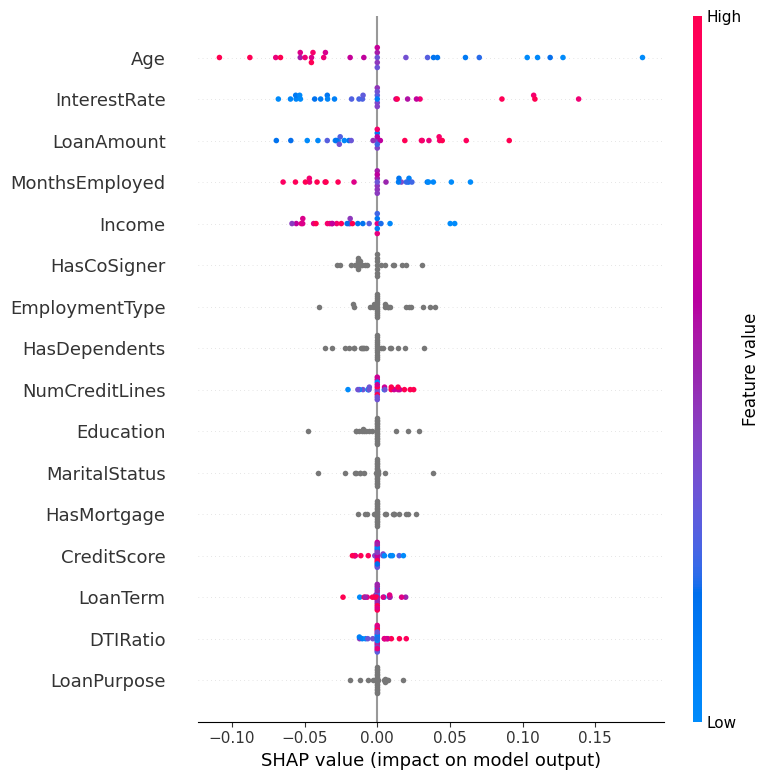

In [16]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    show=True
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

## 8.2) SHAP Bar Plot

In [17]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "shap_summary_bar_plot.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

# 9) LIME

In [18]:
X_train_lime = pd.get_dummies(X_train, drop_first=False)
X_test_lime = pd.get_dummies(X_test, drop_first=False)

X_test_lime = X_test_lime.reindex(
    columns=X_train_lime.columns,
    fill_value=0
)

X_train_lime = X_train_lime.astype(float)
X_test_lime = X_test_lime.astype(float)

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.values,
    feature_names=X_train_lime.columns.tolist(),
    class_names=["Non-Default", "Default"],
    mode="classification"
)

def predict_final_pd_from_encoded(data):

    df_encoded = pd.DataFrame(
        data,
        columns=X_train_lime.columns
    )

    df_original = pd.DataFrame(index=df_encoded.index)

    for col in X_train.columns:

        dummy_cols = [
            c for c in df_encoded.columns
            if c.startswith(f"{col}_")
        ]

        if dummy_cols:

            df_original[col] = (
                df_encoded[dummy_cols]
                .idxmax(axis=1)
                .str[len(col) + 1:]
            )

        else:
            df_original[col] = df_encoded[col]

    pd_raw = get_positive_class_proba(
        predictor,
        df_original,
        model=best_model_final
    )

    pd_be = inv_logit(logit(pd_raw) + alpha_shift)

    moc_a = pd_be * MOC_A_UPLIFT

    moc_c = np.full_like(
        pd_be,
        np.mean(moc_c_test)
    )

    return apply_final_pd_adjustments(
        pd_be=pd_be,
        moc_a=moc_a,
        moc_c=moc_c,
    )

def predict_proba_fn_lime(data):
    pd_final =  predict_final_pd_from_encoded(data)

    return np.column_stack([
        1 - pd_final,
        pd_final
    ])

instance_idx = 0

lime_exp = lime_explainer.explain_instance(
    data_row=X_test_lime.iloc[instance_idx].values,
    predict_fn=predict_proba_fn_lime,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

## 9.1) Save LIME explanation

In [19]:
lime_exp.save_to_file(
    os.path.join(OUT_DIR, "lime_explanation.html")
)

print("Level 3 explainability outputs saved.")

Level 3 explainability outputs saved.


# 10) Global permutation feature importance

In [20]:
# Feature importance computed by shuffling one feature at a time and measuring the resulting performance drop
# Higher values indicate stronger contribution to predictive performance.
# Negative values can indicate that a feature is harmful or unstable.
# Model-Level Explainability (best model)


feature_importance = predictor.feature_importance(
    data=test,
    model=best_model_final,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

print(feature_importance)

feature_importance.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_best_model.csv"),
    index=True
)

                importance    stddev       p_value   n  p99_high   p99_low
Age               0.095625  0.014359  2.878242e-09  10  0.110381  0.080868
Income            0.087699  0.009662  1.841147e-10  10  0.097629  0.077770
InterestRate      0.058469  0.009990  8.985024e-09  10  0.068736  0.048203
LoanAmount        0.055591  0.009029  5.752967e-09  10  0.064870  0.046312
MonthsEmployed    0.031891  0.005020  4.362514e-09  10  0.037050  0.026732
EmploymentType    0.009282  0.004227  3.364765e-05  10  0.013625  0.004938
HasCoSigner       0.006799  0.003479  8.128276e-05  10  0.010374  0.003224
Education         0.003681  0.002577  7.257507e-04  10  0.006329  0.001033
CreditScore       0.003017  0.004041  2.126656e-02  10  0.007170 -0.001136
HasDependents     0.002688  0.002955  9.139645e-03  10  0.005724 -0.000349
LoanPurpose       0.002040  0.002841  2.462961e-02  10  0.004960 -0.000879
MaritalStatus     0.001567  0.002104  2.143088e-02  10  0.003729 -0.000594
HasMortgage       0.00155

# 11) Feature importance for the full AutoGluon predictor

In [21]:
# If the best model is an ensemble --> can be interpreted as the importance of the final "prediction system" rathen than only one base model
# AutoML-System-Level Explainability

feature_importance_final = predictor.feature_importance(
    data=test,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

print(feature_importance_final)

feature_importance_final.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_final_predictor.csv"),
    index=True
)

                importance    stddev       p_value   n  p99_high   p99_low
Age               0.095625  0.014359  2.878242e-09  10  0.110381  0.080868
Income            0.087699  0.009662  1.841147e-10  10  0.097629  0.077770
InterestRate      0.058469  0.009990  8.985024e-09  10  0.068736  0.048203
LoanAmount        0.055591  0.009029  5.752967e-09  10  0.064870  0.046312
MonthsEmployed    0.031891  0.005020  4.362514e-09  10  0.037050  0.026732
EmploymentType    0.009282  0.004227  3.364765e-05  10  0.013625  0.004938
HasCoSigner       0.006799  0.003479  8.128276e-05  10  0.010374  0.003224
Education         0.003681  0.002577  7.257507e-04  10  0.006329  0.001033
CreditScore       0.003017  0.004041  2.126656e-02  10  0.007170 -0.001136
HasDependents     0.002688  0.002955  9.139645e-03  10  0.005724 -0.000349
LoanPurpose       0.002040  0.002841  2.462961e-02  10  0.004960 -0.000879
MaritalStatus     0.001567  0.002104  2.143088e-02  10  0.003729 -0.000594
HasMortgage       0.00155

# 12) Save Outputs

In [22]:
intercept_df = pd.DataFrame({
    "parameter": ["alpha_shift"],
    "value": [float(alpha_shift)],
    "meaning": ["Global logit shift used to align mean PD to proxy LRADR"]
})


# Summaries
validation_summary = pd.DataFrame(
    [
        {"metric": k, "value": v}
        for d in [
            raw_train_metrics,
            raw_test_metrics,
            be_train_metrics,
            be_test_metrics,
            final_train_metrics,
            final_test_metrics,
        ]
        for k, v in d.items()
    ]
)

moc_summary = pd.DataFrame({
    "component": [
        "MoC_A_mean_train",
        "MoC_C_mean_train",
        "Total_MoC_mean_train",
        "MoC_A_mean_test",
        "MoC_C_mean_test",
        "Total_MoC_mean_test",
    ],
    "value": [
        float(np.mean(moc_a_train)),
        float(np.mean(moc_c_train)),
        float(np.mean(moc_a_train + moc_c_train)),
        float(np.mean(moc_a_test)),
        float(np.mean(moc_c_test)),
        float(np.mean(moc_a_test + moc_c_test)),
    ],
    "note": [
        "Method sensitivity component",
        "Bootstrap-based estimation uncertainty component",
        "Mean total margin of conservatism",
        "Method sensitivity component",
        "Bootstrap-based estimation uncertainty component",
        "Mean total margin of conservatism",
    ],
})

explainability_summary = pd.DataFrame({
    "method": [
        "AutoGluon feature importance",
        "Permutation feature importance",
        "SHAP explanations",
        "LIME explanations",
    ],
    "level": [
        "global",
        "global",
        "local/global",
        "local",
    ],
    "source": [
        "AutoGluon built-in",
        "AutoGluon built-in",
        "external post-hoc",
        "external post-hoc",
    ],
    "note": [
        "Global feature importance calculated by AutoGluon on evaluation data",
        "Model-agnostic feature importance based on performance decrease after feature permutation",
        "Local feature attribution and optional global aggregation via mean absolute SHAP values",
        "Local surrogate explanation for selected individual predictions",
    ],
})

method_summary = pd.DataFrame({
    "item": [
        "input_data",
        "model",
        "model_selection",
        "best_estimate_calibration",
        "risk_grade_generation",
        "monotonicity_location",
        "moc_a",
        "moc_b",
        "moc_c",
        "pd_floor",
        "oot_backtest_possible",
        "long_run_historical_calibration_possible",
    ],
    "value": [
        "Raw feature datasets using the same split logic as the WoE pipeline",
        "AutoGluon TabularPredictor",
        f"AutoGluon leaderboard on validation data; best model={best_model_final}",
        f"Global logit shift to target proxy LRADR={proxy_lradr:.6f}",
        "Quantile-based PD grades followed by monotonic observed-DR merging",
        "Post-processing level: calibrated PDs are mapped into ordered risk grades",
        "Proxy-based relative uplift reflecting methodological uncertainty",
        "Not calculated; no time, process, policy, or historical portfolio information available",
        "Bootstrap-based estimation uncertainty approximation",
        f"Mandatory PD floor with value {PD_FLOOR}",
        "No",
        "No",
    ],
})

limitations_text = """
This workflow implements an AutoGluon-based PD modelling pipeline on raw features.
It is designed as an AutoML alternative to a classical WoE/logistic-regression scorecard.

What is feasible here:
- raw-feature AutoML modelling without WoE preprocessing
- discrimination metrics such as AUC, Gini, and KS
- grouped calibration checks
- best-estimate calibration scaffold via global logit shift
- monotonic post-processing through ordered risk-grade mapping
- scorecard-like risk-grade table with PD ranges, observed default rates, and calibration gaps
- feature importance as an AutoML interpretability artefact

What is not equivalent to the classical scorecard:
- no WoE bins are used before model training
- no logistic-regression coefficients are available
- no bin-level logit contributions are available
- coefficient sign review is not applicable
- monotonicity is introduced after model estimation, not at feature-transformation level

What remains impossible or only partially defensible with this dataset:
- out-of-time backtesting, because no observation dates are available
- vintage analysis, because no dates are available
- long-run average default rate from historical cycles, because this is a single snapshot
- segment-specific models or calibration, because no formal portfolio segmentation fields are available
- MoC_B based on policy, process, or business changes over time
- MoC_A and MoC_C are implemented as methodological proxies rather than regulatory capital-model MoCs
- regulatory default definition according to Article 178 CRR cannot be verified from this dataset
- only proxy LRADR due to missing time dimension and missing long-term historical default observations
""".strip()

model_package = {
    "target": TARGET,
    "output_dir": OUT_DIR,
    "autogluon_model_path": f"{OUT_DIR}/ag_model_level3",
    "time_limit": TIME_LIMIT,
    "best_model": str(best_model_final),
    "observed_train_dr": observed_train_dr,
    "proxy_lradr": proxy_lradr,
    "conservatism_uplift": CONSERVATISM_UPLIFT,
    "lradr_type": "proxy",
    "pd_floor": PD_FLOOR,
    "n_risk_grades_requested": N_RISK_GRADES,
    "n_risk_grades_final": int(scorecard_df["final_risk_grade"].nunique()),
    "seed": SEED,
    "n_features_final": int(train_final.shape[1]),
    "features_final": list(train_final.columns),
    "explainability_output_dir": EXPLAIN_DIR,
}


# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------

leaderboard.to_csv(os.path.join(OUT_DIR, "model_selection_table.csv"), index=False)
intercept_df.to_csv(os.path.join(OUT_DIR, "intercepts.csv"), index=False)
feature_importance.to_csv(os.path.join(OUT_DIR, "feature_importance.csv"), index=True)

initial_grade_table.to_csv(os.path.join(OUT_DIR, "initial_risk_grade_table.csv"), index=False)
scorecard_df.to_csv(os.path.join(OUT_DIR, "scorecard_table.csv"), index=False)

pd_results_test.to_csv(os.path.join(OUT_DIR, "pd_results_test.csv"), index=False)
rank_ordering.to_csv(os.path.join(OUT_DIR, "rank_ordering.csv"), index=False)

cal_table_raw.to_csv(os.path.join(OUT_DIR, "calibration_table_raw.csv"), index=False)
cal_table_be.to_csv(os.path.join(OUT_DIR, "calibration_table_be.csv"), index=False)
cal_table_final.to_csv(os.path.join(OUT_DIR, "calibration_table_final.csv"), index=False)

stability_summary.to_csv(os.path.join(OUT_DIR, "stability_summary.csv"), index=False)
validation_summary.to_csv(os.path.join(OUT_DIR, "validation_summary.csv"), index=False)
moc_summary.to_csv(os.path.join(OUT_DIR, "moc_summary.csv"), index=False)
method_summary.to_csv(os.path.join(OUT_DIR, "method_summary.csv"), index=False)
explainability_summary.to_csv(os.path.join(EXPLAIN_DIR, "autogluon_explainability_summary.csv"), index=False)

with open(os.path.join(OUT_DIR, "limitations.txt"), "w", encoding="utf-8") as f:
    f.write(limitations_text)

with open(os.path.join(OUT_DIR, "model_package.json"), "w", encoding="utf-8") as f:
    json.dump(model_package, f, indent=2, default=str)


# ------------------------------------------------------------
# Print summary
# ------------------------------------------------------------

print("Saved outputs to:", OUT_DIR)
print("Best AutoGluon model:", best_model)
print("Train final shape:", train_final.shape)
print("Test final shape:", test_final.shape)
print("Proxy LRADR:", proxy_lradr)
print("Alpha shift:", alpha_shift)
print()
print(validation_summary.head(12))
print()
print(moc_summary)
print()
print("Final monotonic scorecard/rating table:")
print(scorecard_df)


Saved outputs to: /content/autogluon_level3_outputs
Best AutoGluon model: WeightedEnsemble_L3
Train final shape: (204277, 17)
Test final shape: (51070, 17)
Proxy LRADR: 0.15096462156777318
Alpha shift: -1.6837393032983528

               metric          value
0       train_raw_auc       0.779936
1      train_raw_gini       0.559872
2        train_raw_ks       0.413154
3     train_raw_brier       0.196453
4   train_raw_logloss       0.576629
5   train_raw_hl_like  103543.784502
6   train_raw_mean_pd       0.425003
7    train_raw_obs_dr       0.116127
8        test_raw_auc       0.758314
9       test_raw_gini       0.516628
10        test_raw_ks       0.384422
11     test_raw_brier       0.200803

              component     value  \
0      MoC_A_mean_train  0.007548   
1      MoC_C_mean_train  0.025565   
2  Total_MoC_mean_train  0.033114   
3       MoC_A_mean_test  0.007599   
4       MoC_C_mean_test  0.030804   
5   Total_MoC_mean_test  0.038403   

                                   

# 13) Predictions

In [23]:
pd_val_raw = get_positive_class_proba(predictor, val, model=best_model_final)
pd_val_be = inv_logit(logit(pd_val_raw) + alpha_shift)
moc_a_val = pd_val_be * MOC_A_UPLIFT
moc_c_val = np.full_like(pd_val_be, np.mean(moc_c_train), dtype=float)

pd_val_final = apply_final_pd_adjustments(
    pd_be=pd_val_be,
    moc_a=moc_a_val,
    moc_c=moc_c_val,
    pd_floor=PD_FLOOR,
)

y_test_true = y_test_final
y_test_proba = pd_test_be


# 14) Lorenz Curve & Calibration Curve

Discrimination and calibration evaluate different properties:

*   Discrimination: Can the model rank risky and safe borrowers correctly?
*   Calibration: Do predicted PD values match observed default rates?

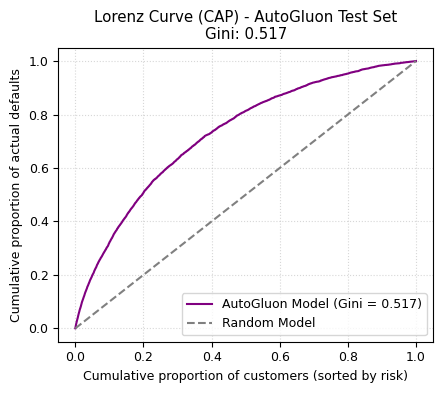

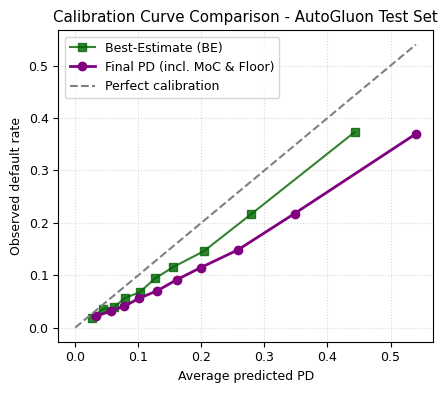

Saved AutoGluon IRBA-compliant plots to: /content/thesis_plots


In [24]:
plt.rcParams.update({
    "font.size": 9
})

# ============================================================
# 1. Lorenz curve (CAP / Cumulative Gains) - AutoGluon
# ============================================================

# Evaluate the discriminatory power of the PD model.
# Customers are sorted from highest predicted risk to lowest.
#
# Interpretation:
# - A curve far above the diagonal indicates strong risk separation.
# - The diagonal represents a random model.
# - The Gini coefficient summarizes discrimination:
#
#   Gini < 0.20  -> weak
#   0.20 - 0.40  -> acceptable
#   0.40 - 0.50  -> good
#   > 0.50       -> strong
#
# In banking practice, Gini is one of the standard measures
# for validating rating systems and PD models.

# Create DataFrame and sort observations by predicted PD
df_lorenz = pd.DataFrame({"y_true": y_test_true, "y_proba": y_test_proba})
df_lorenz = df_lorenz.sort_values(by="y_proba", ascending=False).reset_index(drop=True)

# Cumulative percentage of customers
cum_population = np.arange(1, len(df_lorenz) + 1) / len(df_lorenz)
# Cumulative percentage of observed defaults
cum_defaults = df_lorenz["y_true"].cumsum() / df_lorenz["y_true"].sum()

# Convert ROC-AUC into Gini coefficient
roc_auc = roc_auc_score(y_test_true, y_test_proba)
gini_score = 2 * roc_auc - 1

plt.figure(figsize=(4.5, 4))
plt.plot(cum_population, cum_defaults, color="purple", label=f"AutoGluon Model (Gini = {gini_score:.3f})")
# Random model benchmark
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Model")

plt.xlabel("Cumulative proportion of customers (sorted by risk)")
plt.ylabel("Cumulative proportion of actual defaults")
plt.title(f"Lorenz Curve (CAP) - AutoGluon Test Set\nGini: {gini_score:.3f}")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
lorenz_path = os.path.join(PLOT_DIR, "lorenz_curve_ag_test.png")
plt.savefig(lorenz_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()


# ============================================================
# 2. Combined Calibration Curve (Reliability Diagram) - AutoGluon
# ============================================================
# Purpose:
# Evaluate whether predicted PD values correspond to observed default frequencies.
#
# This plot compares two distinct stages of the IRBA model pipeline:
#
# 1) Best-Estimate (BE) PD:
#    Represents the unbiased estimate of the expected default probability after the
#    alpha-shift calibration step. It is evaluated before applying conservatism adjustments
#    such as MoC_A, MoC_C, or the regulatory PD floor. A well-calibrated BE model should
#    closely follow the diagonal reference line across all risk segments.
#
# 2) Final PD:
#    Evaluated after conservatism adjustments (MoC and the PD floor). Therefore, the final
#    PD is expected to be conservative. For final PDs, points slightly below the diagonal
#    are not necessarily problematic, because MoC intentionally increases the PD estimate.
#    This line indicates the built-in level of regulatory conservatism.
#
# Interpretation:
# - Points on the diagonal indicate perfect calibration.
#
# - Points above the diagonal:
#     Observed default rate > predicted PD -> the model underestimates risk.
#
# - Points below the diagonal:
#     Observed default rate < predicted PD -> the model overestimates risk / applies conservatism.

# 1. Split observations into 10 equally populated risk buckets for Best-Estimate
prob_true_be, prob_pred_be = calibration_curve(
    y_test_final,
    pd_test_be,       # BE-probability after Alpha-shift
    n_bins=10,
    strategy="quantile"
)

# 2. Split observations into 10 equally populated risk buckets for Final PD
prob_true_final, prob_pred_final = calibration_curve(
    y_test_true,
    pd_test_final,     # Final AutoGluon PD (incl. MoC & Floor)
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(4.5, 4))

# Plot Best-Estimate Line (Green)
plt.plot(prob_pred_be, prob_true_be, "s-", color="darkgreen", alpha=0.8, label="Best-Estimate (BE)")

# Plot Final PD Line (Purple für AutoGluon)
plt.plot(prob_pred_final, prob_true_final, "o-", color="purple", lw=2, label="Final PD (incl. MoC & Floor)")

# Perfect calibration benchmark reference line (up to the maximum predicted value)
max_val = max(max(prob_pred_be), max(prob_pred_final)) if len(prob_pred_final) > 0 else 1.0
plt.plot([0, max_val], [0, max_val], linestyle="--", color="gray", label="Perfect calibration")

plt.xlabel("Average predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve Comparison - AutoGluon Test Set")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
calib_path = os.path.join(PLOT_DIR, "calibration_curve_comparison_ag_test.png")
plt.savefig(calib_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved AutoGluon IRBA-compliant plots to:", PLOT_DIR)


## 14.1) Save outputs

In [25]:
# calculate Gini-coefficient
auc_be = roc_auc_score(y_test_final, pd_test_be)
gini_be = 2 * auc_be - 1

auc_final = roc_auc_score(y_test_final, pd_test_final)
gini_final = 2 * auc_final - 1

# Calculate calibration quality using the Brier Score
# Lower values indicate better calibration and probability accuracy.
brier_be = brier_score_loss(y_test_final, pd_test_be)
brier_final = brier_score_loss(y_test_final, pd_test_final)

# Store all evaluation metrics in a DataFrame
irba_metrics_summary = pd.DataFrame({
    "Model_Stage": ["Best-Estimate (BE)", "Final (incl. MoC & Floor)"],
    "Gini_Coefficient": [gini_be, gini_final],
    "Brier_Score_Calibration": [brier_be, brier_final]
})

# save as csv
irba_metrics_summary.to_csv(os.path.join(OUT_DIR, "irba_performance_metrics.csv"), index=False)


print("H2O CORE IRBA PERFORMANCE METRICS (TEST SET)")
print(irba_metrics_summary.to_string(index=False))


H2O CORE IRBA PERFORMANCE METRICS (TEST SET)
              Model_Stage  Gini_Coefficient  Brier_Score_Calibration
       Best-Estimate (BE)          0.516628                 0.092375
Final (incl. MoC & Floor)          0.513732                 0.098614
